In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
import qutip as qt
from tqdm.auto import tqdm

In [ ]:
# System Parameters for Single Symbol Simulation
alpha = 2.0             # Coherent state amplitude (|alpha_0> = |+alpha>, |alpha_1> = |-alpha>)
alpha0 = alpha          # Hypothesis 0 amplitude
alpha1 = -alpha         # Hypothesis 1 amplitude
nu = 2.0                # Dark count rate (counts per second)
T = 1.0                 # Symbol duration (seconds)
dt = 1e-4               # Time step resolution
prior_P0 = 0.5          # Initial prior probability for state |alpha_0>
steps = int(T / dt)


In [ ]:
true_state_idx = 1
true_alpha = alpha0 if true_state_idx == 0 else alpha1

# Initialize tracking variables
P0 = prior_P0
P0_history = np.zeros(steps)
beta_history = np.zeros(steps)
clicks = []

# Continuous time-slice simulation of the optimal Dolinar receiver with off-center displacement
for i in tqdm(range(steps), desc="Simulating Single Symbol"):
    t = i * dt
    P0_history[i] = P0
    
    # 1. Optimal Dolinar off-center displacement field beta(t)
    # Time-to-go offset factor: f(t) = exp(-4 * alpha^2 * (T - t))
    # beta(t) = -alpha * [ (2*P0 - 1) + sqrt(1 - f(t)) ] / [ 1 + (2*P0 - 1)*sqrt(1 - f(t)) ]
    f_t = np.exp(-4.0 * alpha**2 * (T - t))
    denom = np.sqrt(np.maximum(1.0 - f_t, 1e-12))
    x = 2.0 * P0 - 1.0
    beta = -alpha * (x + denom) / (1.0 + x * denom)
    beta_history[i] = beta
    
    # 2. Instantaneous Poisson click rates (displaced signal + dark counts)
    rate0 = np.abs(alpha0 + beta)**2 + nu
    rate1 = np.abs(alpha1 + beta)**2 + nu
    rate_true = np.abs(true_alpha + beta)**2 + nu
    
    # 3. Exact on/off detector click probability in interval dt
    p_click_true = 1.0 - np.exp(-rate_true * dt)
    
    # 4. Bayesian continuous drift and discrete jump state update
    if np.random.rand() < p_click_true:
        # Detector clicked: discrete jump update
        num = P0 * rate0
        den = num + (1.0 - P0) * rate1
        P0 = num / den if den > 0 else 0.5
        clicks.append(t)
    else:
        # No click: continuous deterministic drift update
        num = P0 * np.exp(-rate0 * dt)
        den = num + (1.0 - P0) * np.exp(-rate1 * dt)
        P0 = num / den if den > 0 else 0.5
        
    P0 = np.clip(P0, 1e-12, 1.0 - 1e-12)

# Final decision based on ending posterior probability
decision = 0 if P0 > 0.5 else 1
print(f"Completed: True state = |alpha_{true_state_idx}>, Receiver Decision = |alpha_{decision}>, Total Clicks = {len(clicks)}")


In [ ]:
time_axis = np.linspace(0, T, steps)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Plot Posterior Probability P0(t)
ax1.plot(time_axis, P0_history, label=r'Posterior Probability $P_0(t)$', color='darkmagenta', linewidth=1.8)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Decision Boundary (0.5)')
for click in clicks:
    ax1.axvline(x=click, color='red', linestyle=':', alpha=0.8)
if clicks:
    ax1.axvline(x=clicks[0], color='red', linestyle=':', alpha=0.8, label='Detector Click')
ax1.set_ylabel(r"$P_0(t)$", fontsize=11)
ax1.set_title(f"Optimal Dolinar Receiver: True State $|\\alpha_{true_state_idx}\\rangle$, Decision $|\\alpha_{decision}\\rangle$ (Dark counts $\\nu={nu}$)")
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot Dynamic Off-Center Displacement Field beta(t)
ax2.plot(time_axis, beta_history, label=r'Off-Center LO Displacement $\beta(t)$', color='teal', linewidth=1.8)
ax2.axhline(-alpha, color='blue', linestyle=':', alpha=0.5, label=r'Fixed Kennedy Nulling ($-\alpha$)')
ax2.axhline(alpha, color='orange', linestyle=':', alpha=0.5, label=r'Fixed Kennedy Nulling ($+\alpha$)')
for click in clicks:
    ax2.axvline(x=click, color='red', linestyle=':', alpha=0.8)
ax2.set_xlabel("Time (s)", fontsize=11)
ax2.set_ylabel(r"$\beta(t)$", fontsize=11)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Dolinar (Ideal, P0=0.8):   0%|          | 0/16 [00:00<?, ?it/s]

Dolinar (Dark Counts nu=0.5, P0=0.8):   0%|          | 0/16 [00:00<?, ?it/s]

Dolinar (Imperfect, P0=0.8):   0%|          | 0/16 [00:00<?, ?it/s]

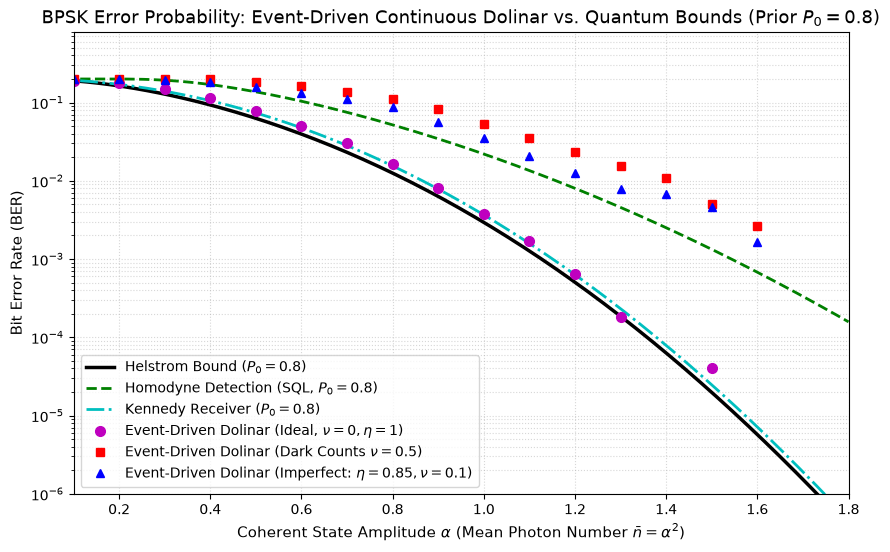

In [26]:
# Theoretical Quantum Bounds for BPSK with Arbitrary Prior Probability
def helstrom_bound(alpha, pi0=0.5):
    """Quantum Helstrom minimum error probability bound for BPSK with prior pi0 = P(H0)"""
    pi1 = 1.0 - pi0
    overlap_sq = np.exp(-4.0 * alpha**2)
    return 0.5 * (1.0 - np.sqrt(np.maximum(1.0 - 4.0 * pi0 * pi1 * overlap_sq, 0.0)))

def homodyne_bound(alpha, pi0=0.5):
    """Standard Quantum Limit (SQL) via ideal homodyne detection with MAP threshold for prior pi0"""
    pi1 = 1.0 - pi0
    # Optimal decision threshold for unequal priors: x_th = (1 / (4*alpha)) * ln(pi1 / pi0)
    # with Gaussian noise variance sigma^2 = 1/4 (sqrt(2)*sigma = 1/sqrt(2))
    x_th = (1.0 / (4.0 * np.maximum(alpha, 1e-6))) * np.log(pi1 / pi0)
    err0 = 0.5 * sp.erfc(np.sqrt(2.0) * (alpha - x_th))
    err1 = 0.5 * sp.erfc(np.sqrt(2.0) * (alpha + x_th))
    return pi0 * err0 + pi1 * err1

def kennedy_bound(alpha, pi0=0.5):
    """Kennedy receiver error probability bound (fixed nulling of state 0)"""
    pi1 = 1.0 - pi0
    return pi1 * np.exp(-4.0 * alpha**2)

# Exact Continuous-Time Event-Driven Simulator with Parameterized Prior
def simulate_event_driven_dolinar(alpha, prior_p0=0.5, nu=0.0, eta=1.0, latency=0.0, T=1.0, trials=5000):
    """
    Simulates the Dolinar receiver directly in continuous time by sampling exact
    Poisson photon arrival timestamps (Gillespie event-driven algorithm).
    """
    # Transmitter generates bits according to prior_p0
    true_states = np.random.choice([0, 1], p=[prior_p0, 1.0 - prior_p0], size=trials)
    true_alphas = np.where(true_states == 0, alpha, -alpha)
    decisions = np.zeros(trials, dtype=int)
    
    for i in range(trials):
        s_alpha = true_alphas[i]
        t = 0.0
        P0 = prior_p0
        
        while t < T:
            # Dynamic off-center displacement at continuous timestamp t
            f_t = np.exp(-4.0 * alpha**2 * (T - t))
            denom = np.sqrt(max(1.0 - f_t, 1e-12))
            x = 2.0 * P0 - 1.0
            beta = -alpha * (x + denom) / (1.0 + x * denom)
            
            rate_signal = np.abs(s_alpha + beta)**2
            rate_total = eta * rate_signal + nu
            
            if rate_total <= 1e-12:
                # No photon can arrive: drift analytically to T
                rate0 = np.abs(alpha + beta)**2 + nu
                rate1 = np.abs(-alpha + beta)**2 + nu
                dt_rem = T - t
                P0 = P0 * np.exp(-rate0 * dt_rem) / (P0 * np.exp(-rate0 * dt_rem) + (1.0 - P0) * np.exp(-rate1 * dt_rem))
                break
                
            # Exact continuous inter-arrival time from Exponential(rate_total)
            delta_t = np.random.exponential(1.0 / rate_total)
            t_next = t + delta_t
            
            if t_next >= T:
                # No click arrived before end of symbol: analytical drift to T
                rate0 = np.abs(alpha + beta)**2 + nu
                rate1 = np.abs(-alpha + beta)**2 + nu
                dt_rem = T - t
                P0 = P0 * np.exp(-rate0 * dt_rem) / (P0 * np.exp(-rate0 * dt_rem) + (1.0 - P0) * np.exp(-rate1 * dt_rem))
                break
            else:
                # Photon arrival at t_next: apply continuous drift then discrete Bayesian jump
                rate0 = np.abs(alpha + beta)**2 + nu
                rate1 = np.abs(-alpha + beta)**2 + nu
                P0 = P0 * np.exp(-rate0 * delta_t) / (P0 * np.exp(-rate0 * delta_t) + (1.0 - P0) * np.exp(-rate1 * delta_t))
                P0 = (P0 * rate0) / (P0 * rate0 + (1.0 - P0) * rate1)
                
                t = t_next + latency
                P0 = np.clip(P0, 1e-12, 1.0 - 1e-12)
                
        decisions[i] = 0 if P0 > 0.5 else 1
        
    return np.mean(decisions != true_states)

def sweep_event_driven_ber(alpha_vals, prior_p0=0.5, nu=0.0, eta=1.0, latency=0.0, trials=5000, desc="Simulating"):
    bers = []
    for a in tqdm(alpha_vals, desc=desc):
        bers.append(simulate_event_driven_dolinar(a, prior_p0=prior_p0, nu=nu, eta=eta, latency=latency, trials=trials))
    return np.array(bers)

# Set Prior Probability for State |alpha_0>
prior_prob = 0.8          # Change to e.g. 0.8 to test asymmetric priors!

# Sweep amplitude alpha and compute BER using the Event-Driven Continuous Simulator
alpha_points = np.linspace(0.1, 1.6, 16)
trials_count = 50000

ber_event_ideal = sweep_event_driven_ber(alpha_points, prior_p0=prior_prob, nu=0.0, eta=1.0, trials=trials_count, desc=f"Dolinar (Ideal, P0={prior_prob})")
ber_event_dark = sweep_event_driven_ber(alpha_points, prior_p0=prior_prob, nu=0.5, eta=1.0, trials=trials_count, desc=f"Dolinar (Dark Counts nu=0.5, P0={prior_prob})")
ber_event_imperfect = sweep_event_driven_ber(alpha_points, prior_p0=prior_prob, nu=0.1, eta=0.85, latency=1e-3, trials=trials_count, desc=f"Dolinar (Imperfect, P0={prior_prob})")

# Smooth theoretical curves for the chosen prior probability
alpha_grid = np.linspace(0.05, 1.8, 200)

plt.figure(figsize=(10, 6))
plt.semilogy(alpha_grid, helstrom_bound(alpha_grid, pi0=prior_prob), 'k-', linewidth=2.5, label=f'Helstrom Bound ($P_0={prior_prob}$)')
plt.semilogy(alpha_grid, homodyne_bound(alpha_grid, pi0=prior_prob), 'g--', linewidth=2.0, label=f'Homodyne Detection (SQL, $P_0={prior_prob}$)')
plt.semilogy(alpha_grid, kennedy_bound(alpha_grid, pi0=prior_prob), 'c-.', linewidth=2.0, label=f'Kennedy Receiver ($P_0={prior_prob}$)')

plt.semilogy(alpha_points, ber_event_ideal, 'mo', markersize=7, label=f'Event-Driven Dolinar (Ideal, $\\nu=0, \\eta=1$)')
plt.semilogy(alpha_points, ber_event_dark, 'rs', markersize=6, label=f'Event-Driven Dolinar (Dark Counts $\\nu=0.5$)')
plt.semilogy(alpha_points, ber_event_imperfect, 'b^', markersize=6, label=f'Event-Driven Dolinar (Imperfect: $\\eta=0.85, \\nu=0.1$)')

plt.title(f'BPSK Error Probability: Event-Driven Continuous Dolinar vs. Quantum Bounds (Prior $P_0={prior_prob}$)', fontsize=13)
plt.xlabel(r'Coherent State Amplitude $\alpha$ (Mean Photon Number $\bar{n}=\alpha^2$)', fontsize=11)
plt.ylabel('Bit Error Rate (BER)', fontsize=11)
plt.ylim(1e-6, 0.8)
plt.xlim(0.1, 1.8)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='best', fontsize=10)
plt.show()